# Steam pricing and review patterns

This exploratory project compares the average share of positive reviews across price bands, first-listed genres, and free/paid titles. It describes associations, not the effect of changing a game's price.

This version runs from the supplied prepared extracts. The original notebook reported 125,855 raw records and 30,624 with at least 50 reviews; those upstream counts and the header repair cannot be independently reproduced without the original games.csv. The paid extract contains 26,471 records with a nonmissing genre and prices greater than zero and no more than $70. The comparison extract includes 4,062 free records. Source URL, snapshot date, currency and redistribution permission still need confirmation.

Each title receives equal weight in the mean review score. This differs from pooling every review across all titles. At least 50 reviews is an inclusion rule, not a guarantee of statistical reliability.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

paid = pd.read_csv("games_clean.csv")
combined = pd.read_csv("free_vs_paid.csv")
free = combined.loc[combined["type"].eq("Free")].copy()
band_order = ["Under $5", "$5-10", "$10-20", "$20-30", "$30-40", "$40-70"]
bucket_order = ["50-200", "200-1k", "1k-10k", "10k+"]
paid["main_genre"] = paid["Genres"].str.split(",").str[0]
# Compatibility name only: main_genre means FIRST-LISTED genre, not verified primary genre.
assert paid["Price"].gt(0).all() and paid["Price"].le(70).all()
assert paid["total_reviews"].ge(50).all()
assert paid["Positive"].ge(0).all() and paid["Negative"].ge(0).all()
assert paid["total_reviews"].eq(paid["Positive"] + paid["Negative"]).all()
assert (paid["review_score"] - paid["Positive"] / paid["total_reviews"]).abs().lt(1e-10).all()
assert combined["review_score"].between(0,1).all()
assert combined["total_reviews"].ge(50).all()
assert set(combined["type"]) == {"Free", "Paid"}
expected_band = pd.cut(paid["Price"], [0,5,10,20,30,40,71], right=False, labels=band_order)
assert expected_band.astype(str).eq(paid["price_band"]).all()
def review_bucket(n):
    return "50-200" if n < 200 else "200-1k" if n < 1000 else "1k-10k" if n < 10000 else "10k+"
assert combined["total_reviews"].map(review_bucket).eq(combined["review_bucket"]).all()
left = paid[["review_score","total_reviews"]].sort_values(["review_score","total_reviews"]).reset_index(drop=True)
right = combined.loc[combined["type"].eq("Paid"), ["review_score","total_reviews"]].sort_values(["review_score","total_reviews"]).reset_index(drop=True)
pd.testing.assert_frame_equal(left, right, check_exact=False, atol=1e-10, rtol=1e-10)
print(f"Validated {len(paid):,} paid records and {len(combined):,} comparison records.")
print("Repeated names:", paid["Name"].duplicated().sum())
print("Identical prepared rows:", paid.duplicated().sum())
print("Rows are retained: recover AppID from the raw source before deciding whether to deduplicate.")


Validated 26,471 paid records and 30,533 comparison records.
Repeated names: 88
Identical prepared rows: 1
Rows are retained: recover AppID from the raw source before deciding whether to deduplicate.


## How do average scores differ across price bands?
Bands use lower-inclusive, upper-exclusive boundaries, except the final band includes $70. For example, $5-10 means $5 to less than $10.

In [2]:
band_order = ["Under $5", "$5-10", "$10-20", "$20-30", "$30-40", "$40-70"]

summary = paid.groupby("price_band").agg(
    avg_score=("review_score", "mean"),
    num_games=("review_score", "count")
).reindex(band_order)

summary["avg_score"] = (summary["avg_score"] * 100).round(1)
print(summary)

            avg_score  num_games
price_band                      
Under $5         77.5      16102
$5-10            81.5       5901
$10-20           80.8       3638
$20-30           79.3        580
$30-40           78.2        136
$40-70           75.2        114


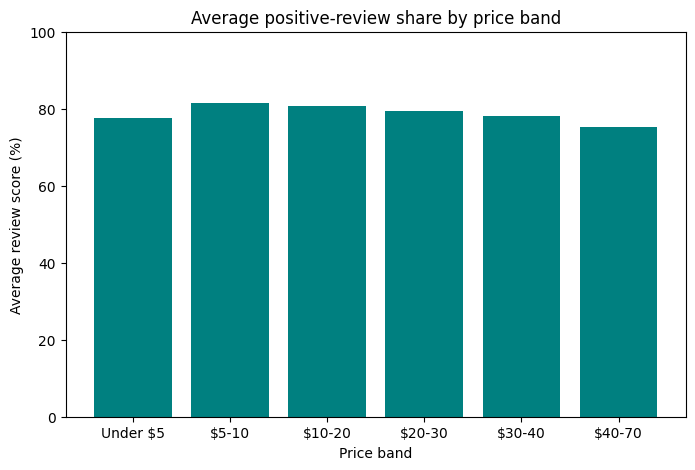

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(summary.index, summary["avg_score"], color="teal")
plt.ylabel("Average review score (%)")
plt.xlabel("Price band")
plt.title("Average positive-review share by price band")
plt.ylim(0, 100)
plt.show()

## Sample sizes and review counts
Higher-priced groups have fewer titles. More reviews can improve information about an individual title, but do not replace having more independent titles for a group comparison.

In [4]:
review_check = paid.groupby("price_band").agg(
    num_games=("total_reviews", "count"),
    avg_reviews_per_game=("total_reviews", "mean"),
    total_reviews=("total_reviews", "sum")
).reindex(band_order)

review_check["avg_reviews_per_game"] = review_check["avg_reviews_per_game"].round(0)
print(review_check)

            num_games  avg_reviews_per_game  total_reviews
price_band                                                
Under $5        16102                2722.0       43832102
$5-10            5901                4704.0       27757036
$10-20           3638                5725.0       20828369
$20-30            580               13566.0        7868039
$30-40            136               31033.0        4220506
$40-70            114               33991.0        3874953


## A first-listed Action subgroup check
This checks whether the pattern appears in one subset. Genre lists are often alphabetically ordered; first-listed genre is a simplifying proxy, not a verified primary genre. This check does not isolate a causal price effect.

In [5]:
# First-listed genre is a proxy; source ordering may be alphabetical.
paid["main_genre"] = paid["Genres"].str.split(",").str[0]

for band in band_order:
    top = paid[paid["price_band"] == band]["main_genre"].value_counts().head(3)
    print(f"\n{band}:")
    print(top)


Under $5:
main_genre
Action       6784
Adventure    3887
Casual       2674
Name: count, dtype: int64

$5-10:
main_genre
Action       2434
Adventure    1505
Indie         709
Name: count, dtype: int64

$10-20:
main_genre
Action       1557
Adventure     866
Indie         447
Name: count, dtype: int64

$20-30:
main_genre
Action       250
Adventure    102
Indie         50
Name: count, dtype: int64

$30-40:
main_genre
Action        53
Adventure     17
Simulation    15
Name: count, dtype: int64

$40-70:
main_genre
Action        32
Simulation    20
Indie         14
Name: count, dtype: int64


In [6]:
# same analysis, action only - does the pattern survive within one genre?
action = paid[paid["main_genre"] == "Action"]

action_summary = action.groupby("price_band").agg(
    avg_score=("review_score", "mean"),
    num_games=("review_score", "count")
).reindex(band_order)

action_summary["avg_score"] = (action_summary["avg_score"] * 100).round(1)
print(action_summary)

            avg_score  num_games
price_band                      
Under $5         76.5       6784
$5-10            80.6       2434
$10-20           79.5       1557
$20-30           76.6        250
$30-40           79.0         53
$40-70           77.7         32


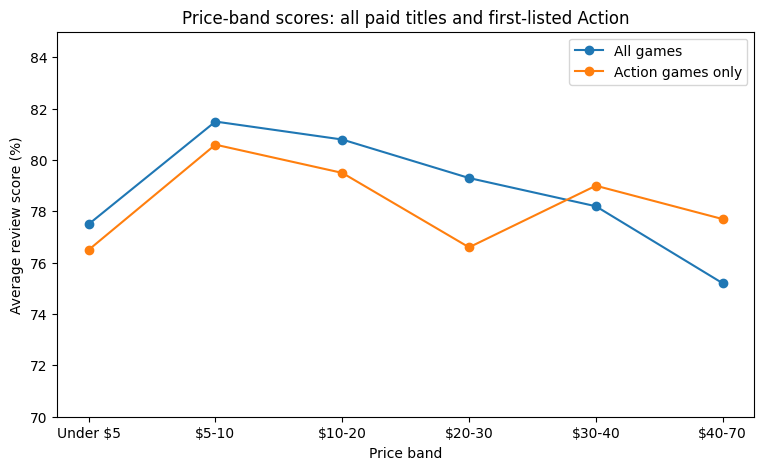

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(band_order, summary["avg_score"], marker="o", label="All games")
ax.plot(band_order, action_summary["avg_score"], marker="o", label="Action games only")
ax.set_ylabel("Average review score (%)")
ax.set_xlabel("Price band")
ax.set_title("Price-band scores: all paid titles and first-listed Action")
ax.set_ylim(70, 85)
ax.legend()
plt.show()

## Free versus paid records
Both groups require at least 50 reviews. Paid titles also require a genre and price no greater than $70; the free extract was not filtered identically. Treat this as a comparison of these selected samples. Review count is a visibility proxy, not sales or unique players.

In [8]:
free_score = free["review_score"].mean() * 100
paid_score = paid["review_score"].mean() * 100

print("Average review score:")
print("  Free games:", round(free_score, 1), "%  (", len(free), "games )")
print("  Paid games:", round(paid_score, 1), "%  (", len(paid), "games )")

Average review score:
  Free games: 76.2 %  ( 4062 games )
  Paid games: 78.9 %  ( 26471 games )


## Scores by first-listed genre
Only groups with at least 100 records are shown. The threshold avoids very small groups but does not establish statistical significance.

In [9]:
# skip genres with <100 games
genre_scores = paid.groupby("main_genre").agg(
    avg_score=("review_score", "mean"),
    num_games=("review_score", "count")
)

genre_scores = genre_scores[genre_scores["num_games"] >= 100]
genre_scores["avg_score"] = (genre_scores["avg_score"] * 100).round(1)
genre_scores = genre_scores.sort_values("avg_score", ascending=False)
print(genre_scores)

            avg_score  num_games
main_genre                      
Adventure        81.4       6383
Casual           80.3       3624
Indie            78.9       2791
RPG              78.9        632
Strategy         77.9        522
Action           77.8      11110
Racing           74.7        209
Simulation       73.5        780


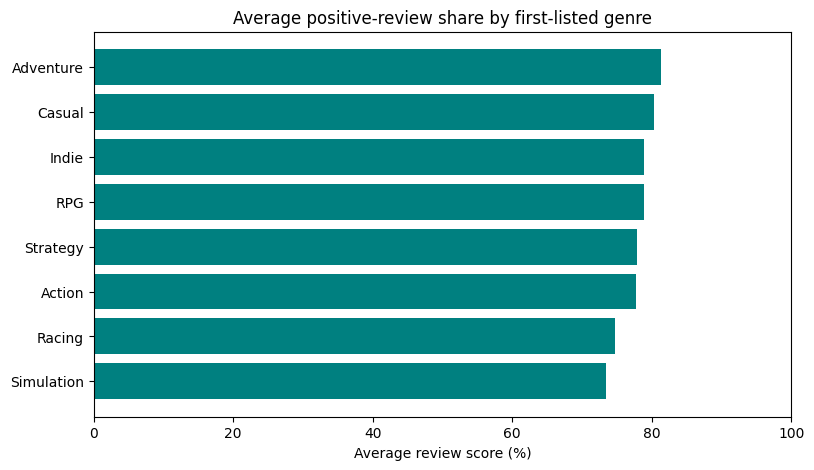

In [10]:
plt.figure(figsize=(9, 5))
plt.barh(genre_scores.index, genre_scores["avg_score"], color="teal")
plt.xlabel("Average review score (%)")
plt.title("Average positive-review share by first-listed genre")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.show()

## Review volume and free/paid differences
Buckets are 50–199, 200–999, 1,000–9,999, and 10,000+ reviews.

In [11]:
# bucket games by how many reviews they have
def review_bucket(n):
    if n < 200:
        return "50-200"
    elif n < 1000:
        return "200-1k"
    elif n < 10000:
        return "1k-10k"
    else:
        return "10k+"

bucket_order = ["50-200", "200-1k", "1k-10k", "10k+"]

# label both groups, then average score per bucket for each
paid["review_bucket"] = paid["total_reviews"].apply(review_bucket)
free["review_bucket"] = free["total_reviews"].apply(review_bucket)

paid_by_bucket = paid.groupby("review_bucket")["review_score"].mean().reindex(bucket_order) * 100
free_by_bucket = free.groupby("review_bucket")["review_score"].mean().reindex(bucket_order) * 100

print("Paid:\n", paid_by_bucket.round(1))
print("\nFree:\n", free_by_bucket.round(1))

Paid:
 review_bucket
50-200    76.3
200-1k    78.9
1k-10k    83.1
10k+      86.7
Name: review_score, dtype: float64

Free:
 review_bucket
50-200    74.3
200-1k    76.2
1k-10k    79.1
10k+      81.3
Name: review_score, dtype: float64


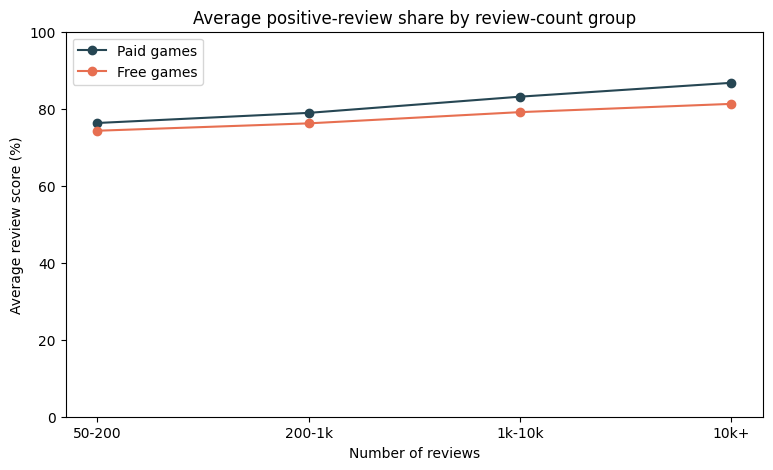

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(bucket_order, paid_by_bucket, marker="o", label="Paid games", color="#264653")
ax.plot(bucket_order, free_by_bucket, marker="o", label="Free games", color="#e76f51")

ax.set_ylabel("Average review score (%)")
ax.set_xlabel("Number of reviews")
ax.set_title("Average positive-review share by review-count group")
ax.set_ylim(0, 100)
ax.legend()
plt.show()

## Sensitivity to the minimum review count
Recalculate price-band summaries using stricter inclusion thresholds. A change in the best-scoring band suggests the conclusion depends on which titles enter the sample. These are descriptive checks, not significance tests.


In [13]:
sensitivity = []
for threshold in [50, 200, 1000]:
    part = paid.loc[paid["total_reviews"].ge(threshold)]
    result = part.groupby("price_band").agg(num_games=("review_score","size"), avg_score=("review_score","mean"))
    result = result.reindex(band_order).reset_index()
    result["avg_score"] = (result["avg_score"] * 100).round(2)
    result["minimum_reviews"] = threshold
    sensitivity.append(result)
sensitivity = pd.concat(sensitivity, ignore_index=True)
print(sensitivity.to_string(index=False))
Path("outputs").mkdir(exist_ok=True)
sensitivity.to_csv("outputs/review_threshold_sensitivity.csv", index=False)


price_band  num_games  avg_score  minimum_reviews
  Under $5      16102      77.54               50
     $5-10       5901      81.48               50
    $10-20       3638      80.82               50
    $20-30        580      79.32               50
    $30-40        136      78.22               50
    $40-70        114      75.16               50
  Under $5       8055      79.92              200
     $5-10       3408      83.13              200
    $10-20       2323      82.58              200
    $20-30        447      80.56              200
    $30-40         98      79.03              200
    $40-70         75      73.30              200
  Under $5       3084      83.64             1000
     $5-10       1567      85.03             1000
    $10-20       1137      84.57             1000
    $20-30        273      81.74             1000
    $30-40         63      81.65             1000
    $40-70         52      73.00             1000


## All-genre membership check
As an alternative to the first-listed proxy, count each title in every listed genre. Groups overlap, so their counts must not be added together as unique titles. This also retains source categories that describe software or content tags.


In [14]:
memberships = paid.assign(genre=paid["Genres"].str.split(",")).explode("genre")
memberships["genre"] = memberships["genre"].str.strip()
genre_memberships = memberships.groupby("genre").agg(num_memberships=("review_score","size"), avg_score=("review_score","mean"))
genre_memberships = genre_memberships.loc[genre_memberships["num_memberships"].ge(100)].copy()
genre_memberships["avg_score"] = (genre_memberships["avg_score"]*100).round(2)
print(genre_memberships.sort_values("avg_score",ascending=False).to_string())
genre_memberships.to_csv("outputs/all_genre_memberships.csv")


                       num_memberships  avg_score
genre                                            
Casual                            8777      79.87
Adventure                        11782      79.38
Indie                            18370      79.23
RPG                               5997      78.63
Design & Illustration              122      77.83
Action                           11185      77.71
Strategy                          5830      77.07
Sports                            1128      76.64
Simulation                        6557      76.46
Racing                             925      75.95
Utilities                          174      75.59
Early Access                      1817      75.44
Massively Multiplayer              400      69.48


## Findings and limits
- With the original 50-review rule, the $5 to under $10 group has the highest mean positive-review share (81.5%). The $40–70 group has the lowest (75.2%); the under-$5 group averages 77.5%.
- The $5 to under $10 group also leads within first-listed Action titles. This does not prove price causes better reviews.
- Paid records average 78.9% and free records 76.2%, under the different selection rules described above. The descriptive gap is wider in higher review-count buckets.
- Among first-listed groups with at least 100 records, Adventure and Casual score highest. Interpret this alongside the overlapping all-genre check.
- Scores are lifetime review proportions compared with a snapshot price; discounts, release age, audience and other factors can matter. No optimal launch price, revenue effect or causal effect is established.
- The $70 cap is a scope choice, not a validated method for excluding software. Software categories remain. Recover raw identifiers and metadata for stronger product classification.
- Review source provenance, snapshot date, currency, and redistribution rights before public release. No raw-to-clean reproducibility claim is made from the supplied extracts alone.
